In [ ]:
# Instalación de dependencias
!pip install -q mlxtend google-genai sqlalchemy networkx matplotlib pandas numpy scikit-learn

In [ ]:
import os
import json

print(">>> PREPARANDO ENTORNO DE METADATOS CLÍNICOS <<<")

# 1. Creación de directorios
os.makedirs('data', exist_ok=True)

# 2. Registro del nuevo producto (Simulación del registro del representante)
splash_tears_data = {
  "SPLASH TEARS": {
    "sub_familia": "Lubricante ocular",
    "mecanismo": "lubricante hidratante lagrimal ocular hipromelosa",
    "indicacion": "ojo seco leve irritación",
    "composicion": "hipromelosa solución oftálmica",
    "formato": "Gotas",
    "es_nuevo": True
  }
}

# 3. Persistencia en la nube
with open('data/productos_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(splash_tears_data, f, ensure_ascii=False, indent=2)

print("✅ Directorio 'data' y 'productos_metadata.json' creados exitosamente.")

>>> PREPARANDO ENTORNO DE METADATOS CLÍNICOS <<<
✅ Directorio 'data' y 'productos_metadata.json' creados exitosamente.


In [ ]:
%%writefile content_recommender.py
import json
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

CONOCIMIENTO_BASE = {
    "LAGRICEL": {"sub_familia": "Lubricante ocular", "mecanismo": "lubricante hidratante lagrimal hialuronato sodio viscosidad retención acuosa", "indicacion": "ojo seco síndrome ojo seco irritación ocular sequedad lubricación", "composicion": "hialuronato de sodio 0.15% solución oftálmica", "formato": "Gotas", "es_nuevo": False},
    "LAGRICEL PF": {"sub_familia": "Lubricante ocular sin conservantes", "mecanismo": "lubricante hidratante lagrimal hialuronato sodio sin conservantes preservante", "indicacion": "ojo seco severo intolerancia conservantes uso frecuente lubricación", "composicion": "hialuronato de sodio libre de conservadores monodosis", "formato": "Gotas monodosis", "es_nuevo": False},
    "ELIPTIC": {"sub_familia": "Lubricante ocular", "mecanismo": "lubricante hidratante lagrimal carboximetilcelulosa estabilización película lagrimal", "indicacion": "ojo seco irritación sequedad ocular lubricación protección corneal", "composicion": "carboximetilcelulosa sódica solución oftálmica", "formato": "Gotas", "es_nuevo": False},
    "ELIPTIC PF": {"sub_familia": "Lubricante ocular sin conservantes", "mecanismo": "lubricante hidratante lagrimal carboximetilcelulosa sin conservantes preservante", "indicacion": "ojo seco severo intolerancia conservantes lubricación protección corneal", "composicion": "carboximetilcelulosa sódica libre de conservadores", "formato": "Gotas monodosis", "es_nuevo": False},
    "GAAP": {"sub_familia": "Lubricante ocular", "mecanismo": "lubricante hidratante lagrimal polivinilpirrolidona glicol propileno viscosidad", "indicacion": "ojo seco irritación sequedad ocular lubricación confort visual", "composicion": "polivinilpirrolidona polietilenglicol solución oftálmica", "formato": "Gotas", "es_nuevo": False},
    "GAAP PF": {"sub_familia": "Lubricante ocular sin conservantes", "mecanismo": "lubricante hidratante lagrimal polivinilpirrolidona sin conservantes preservante", "indicacion": "ojo seco severo intolerancia conservantes lubricación confort visual", "composicion": "polivinilpirrolidona polietilenglicol libre de conservadores", "formato": "Gotas monodosis", "es_nuevo": False},
    "AQUADRAN": {"sub_familia": "Lubricante ocular gel", "mecanismo": "lubricante hidratante gel carbómero retención prolongada película lagrimal nocturno", "indicacion": "ojo seco severo nocturno sequedad extrema protección corneal gel", "composicion": "carbómero gel oftálmico", "formato": "Gel", "es_nuevo": False},
    "DUSTALOX": {"sub_familia": "Antibiótico antiinflamatorio ocular", "mecanismo": "corticoide antibiótico dexametasona tobramicina antiinflamatorio antibacteriano", "indicacion": "inflamación ocular infección bacteriana blefaritis conjuntivitis bacteriana postquirúrgico", "composicion": "dexametasona 0.1% tobramicina 0.3% suspensión oftálmica", "formato": "Gotas", "es_nuevo": False},
    "FLUMETOL NF": {"sub_familia": "Corticoide ocular", "mecanismo": "corticoide fluorometolona antiinflamatorio esteroide ocular", "indicacion": "inflamación ocular no infecciosa queratoconjuntivitis alergica postquirúrgico uveítis anterior", "composicion": "fluorometolona 0.1% suspensión oftálmica", "formato": "Gotas", "es_nuevo": False},
    "SOPHIPREN": {"sub_familia": "Corticoide ocular", "mecanismo": "corticoide prednisolona antiinflamatorio esteroide potente ocular", "indicacion": "inflamación ocular severa uveítis postquirúrgico queratitis corticoide", "composicion": "prednisolona acetato 1% suspensión oftálmica", "formato": "Gotas", "es_nuevo": False},
    "ELAR-B": {"sub_familia": "Corticoide antibiótico ocular", "mecanismo": "corticoide antibiótico betametasona antiinflamatorio antibacteriano combinado", "indicacion": "inflamación ocular infección bacteriana combinada blefaroconjuntivitis", "composicion": "betametasona neomicina solución oftálmica", "formato": "Gotas", "es_nuevo": False},
    "TRAZIDEX O": {"sub_familia": "Antibiótico antiinflamatorio ocular", "mecanismo": "antibiótico antiinflamatorio tramadol dexametasona bactericida ocular gotas", "indicacion": "conjuntivitis bacteriana blefaritis infección ocular postquirúrgico antibacteriano", "composicion": "tobramicina dexametasona solución oftálmica", "formato": "Gotas", "es_nuevo": False},
    "TRAZIDEX U": {"sub_familia": "Antibiótico antiinflamatorio ungüento", "mecanismo": "antibiótico antiinflamatorio tobramicina dexametasona ungüento bactericida ocular nocturno", "indicacion": "conjuntivitis bacteriana blefaritis infección ocular ungüento nocturno", "composicion": "tobramicina dexametasona ungüento oftálmico", "formato": "Ungüento", "es_nuevo": False},
    "ZEBESTEN": {"sub_familia": "Antihistamínico antialérgico ocular", "mecanismo": "antihistamínico estabilizador mastocitos ketotifeno antialérgico antipruriginoso", "indicacion": "alergia ocular conjuntivitis alérgica prurito ocular picazón lagrimeo alérgico", "composicion": "ketotifeno 0.025% solución oftálmica", "formato": "Gotas", "es_nuevo": False},
    "AGGLAD": {"sub_familia": "Antihistamínico antialérgico ocular", "mecanismo": "antihistamínico antialérgico olopatadina bloqueador H1 mastocitos estabilizador", "indicacion": "conjuntivitis alérgica alergia ocular prurito picazón lagrimeo rojez alérgica", "composicion": "olopatadina 0.1% solución oftálmica", "formato": "Gotas", "es_nuevo": False},
    "LANDAX": {"sub_familia": "Antihistamínico antialérgico ocular", "mecanismo": "antihistamínico antialérgico epinastina bloqueador H1 estabilizador mastocitos", "indicacion": "conjuntivitis alérgica alergia ocular prurito picazón lagrimeo estacional", "composicion": "epinastina 0.05% solución oftálmica", "formato": "Gotas", "es_nuevo": False},
}

METADATA_JSON_PATH = Path(__file__).resolve().parent / "data" / "productos_metadata.json"

def cargar_metadatos_nuevos(ruta: Path = METADATA_JSON_PATH) -> dict:
    if ruta.exists():
        with open(ruta, "r", encoding="utf-8") as f: return json.load(f)
    return {}

def _texto_clinico(meta: dict) -> str:
    partes = [meta.get("sub_familia", ""), meta.get("mecanismo", ""), meta.get("indicacion", ""), meta.get("composicion", ""), meta.get("formato", "")]
    return " ".join(p for p in partes if p).lower()

class MotorContenido:
    UMBRAL = 0.05
    def __init__(self, df_compras: pd.DataFrame = None, ruta_json: Path = METADATA_JSON_PATH):
        registro = {k: dict(v) for k, v in CONOCIMIENTO_BASE.items()}
        nuevos = cargar_metadatos_nuevos(ruta_json)
        for clave, meta in nuevos.items():
            registro[clave] = {**meta, "es_nuevo": True}
        self.registro = registro
        self.productos = list(registro.keys())
        corpus = [_texto_clinico(registro[p]) for p in self.productos]
        self._vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=1, max_df=0.95, sublinear_tf=True)
        self._tfidf_matrix = self._vectorizer.fit_transform(corpus)
        self.p2i = {p: i for i, p in enumerate(self.productos)}

    def hay_productos_nuevos(self) -> bool:
        return any(m.get("es_nuevo") for m in self.registro.values())

    def productos_nuevos(self) -> list:
        return [p for p, m in self.registro.items() if m.get("es_nuevo")]

    def similitud_par(self, prod_a: str, prod_b: str) -> float:
        ka, kb = prod_a.upper().strip(), prod_b.upper().strip()
        if ka not in self.p2i or kb not in self.p2i: return 0.0
        ia, ib = self.p2i[ka], self.p2i[kb]
        sim = cosine_similarity(self._tfidf_matrix[ia], self._tfidf_matrix[ib])[0][0]
        return round(float(sim), 4)

    def score(self, historial_nombres: list, producto_nuevo: str) -> tuple:
        clave = producto_nuevo.upper().strip()
        if clave not in self.p2i: return 0.0, "", ""
        mejor_score, mejor_prod, mejor_razon = 0.0, "", ""
        for prod in historial_nombres:
            sim = self.similitud_par(clave, prod)
            if sim > mejor_score:
                mejor_score, mejor_prod = sim, prod
                meta_nuevo = self.registro.get(clave, {})
                meta_hist  = self.registro.get(prod.upper().strip(), {})
                partes_razon = []
                if meta_hist.get("sub_familia") == meta_nuevo.get("sub_familia"): partes_razon.append(f"misma sub-familia terapéutica ({meta_nuevo.get('sub_familia')})")
                if meta_hist.get("formato") == meta_nuevo.get("formato"): partes_razon.append("mismo formato de administración")
                palabras_n = set(_texto_clinico(meta_nuevo).split())
                palabras_h = set(_texto_clinico(meta_hist).split())
                comunes = palabras_n & palabras_h - {"de", "y", "el", "la", "en"}
                if comunes:
                    top = sorted(comunes, key=len, reverse=True)[:2]
                    partes_razon.append(f"principios activos relacionados: {', '.join(top)}")
                mejor_razon = "; ".join(partes_razon) if partes_razon else "afinidad de perfil terapéutico"
        return round(mejor_score, 4), mejor_prod, mejor_razon

    def recomendar_nuevos(self, historial_nombres: list, top_k: int = 3) -> list:
        historial_upper = {h.upper().strip() for h in historial_nombres}
        resultados = []
        for prod_nuevo in self.productos_nuevos():
            if prod_nuevo in historial_upper: continue
            s, match, razon = self.score(historial_nombres, prod_nuevo)
            if s >= self.UMBRAL:
                meta = self.registro[prod_nuevo]
                resultados.append({
                    "producto": prod_nuevo, "score": s, "similar_a": match, "razon_xai": razon,
                    "sub_familia": meta.get("sub_familia", ""), "indicacion": meta.get("indicacion", ""),
                    "composicion": meta.get("composicion", ""), "motor": "Contenido (Nuevo Lanzamiento)", "es_nuevo": True,
                })
        resultados.sort(key=lambda x: x["score"], reverse=True)
        return resultados[:top_k]

def inyectar_candidatos_nuevos(motor: MotorContenido, historial_nombres: list, mapa_nombre_a_id: dict) -> list:
    nuevos = motor.recomendar_nuevos(historial_nombres)
    candidatos = []
    for rec in nuevos:
        nombre  = rec["producto"]
        prod_id = mapa_nombre_a_id.get(nombre, f"NUEVO_{nombre}")
        candidatos.append((prod_id, rec["motor"], rec["score"], rec))
    return candidatos

Overwriting content_recommender.py


In [ ]:
import os
import pandas as pd
import numpy as np
import warnings
import networkx as nx
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from google.colab import userdata
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from mlxtend.frequent_patterns import apriori, association_rules
from google import genai
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')

print(">>> CONECTANDO A LA BASE DE DATOS Y CARGANDO HISTORIAL <<<")

def cargar_datos():
    db_uri = userdata.get('DATABASE_URL')
    try:
        engine = create_engine(db_uri)
        compras = pd.read_sql_query("SELECT * FROM ventas_detalle", con=engine)
        print("✅ Conexión exitosa a la base de datos B2B.")
        return compras
    except Exception as e:
        print(f"⚠️ Error conectando a DB, revisa tus credenciales: {e}")
        return None

compras_ctx = cargar_datos()

if compras_ctx is not None:
    col_zona = next((c for c in ['vendedor', 'zona'] if c in compras_ctx.columns), None)
    col_cliente = next((c for c in ['cliente', 'nombre_cliente', 'Cliente'] if c in compras_ctx.columns), None)
    mapa_productos = compras_ctx.drop_duplicates('producto_id').set_index('producto_id')['producto'].to_dict()

    mes_col_existe = False
    for col_fecha in ['fecha', 'date', 'fecha_pedido']:
        if col_fecha in compras_ctx.columns:
            compras_ctx['mes'] = pd.to_datetime(compras_ctx[col_fecha], errors='coerce').dt.month.fillna(1).astype(int)
            mes_col_existe = True
            break
    if not mes_col_existe:
        compras_ctx['mes'] = compras_ctx.get('mes_num', pd.Series([1]*len(compras_ctx))).fillna(1).astype(int)

    # Diccionario de precios (con contingencia para NaN)
    if 'monto_cancelado' in compras_ctx.columns:
        compras_ctx['precio_unit'] = compras_ctx['monto_cancelado'] / compras_ctx['cantidad'].replace(0, 1)
        precios_dict = compras_ctx.groupby('producto')['precio_unit'].median().to_dict()
    else:
        np.random.seed(42)
        precios_dict = {prod: round(np.random.uniform(15.0, 85.0), 2) for prod in compras_ctx['producto'].unique()}

    print(f"✅ Total de transacciones preparadas: {len(compras_ctx)}")

>>> CONECTANDO A LA BASE DE DATOS Y CARGANDO HISTORIAL <<<
✅ Conexión exitosa a la base de datos B2B.
✅ Total de transacciones preparadas: 4717


In [ ]:
def entrenar_modelos_ml(df, k_clusters, min_sup, min_lift):
    df_rfm = df.groupby('cliente_id').agg(
        Volumen=('cantidad', 'sum'),
        Variedad=('producto_id', 'nunique'),
        Frecuencia=('mes', 'nunique')
    ).fillna(0)

    scaler = StandardScaler()
    rfm_scaled = scaler.fit_transform(df_rfm)

    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    df_rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
    cluster_dict = df_rfm['Cluster'].to_dict()

    cesta = df.groupby(['cliente_id', 'producto'])['cantidad'].sum().unstack().reset_index().fillna(0)
    cesta_bool = (cesta.drop('cliente_id', axis=1) > 0).astype(bool)

    itemsets_frecuentes = apriori(cesta_bool, min_support=min_sup, use_colnames=True)
    reglas = association_rules(itemsets_frecuentes, metric="lift", min_threshold=min_lift) if not itemsets_frecuentes.empty else pd.DataFrame(columns=['antecedents', 'consequents', 'confidence', 'lift'])

    df_con_cluster = df.merge(df_rfm[['Cluster']], left_on='cliente_id', right_index=True)
    volumenes_cluster = df_con_cluster.groupby(['Cluster', 'producto'])['cantidad'].median().to_dict()

    return cluster_dict, reglas, df_rfm, volumenes_cluster

def pasa_filtros_seguridad(producto_sugerido, historial_cliente, zona_actual, motor_origen, compras_df, col_z):
    if 'sin_stock' in compras_df.columns:
        quiebres = compras_df[(compras_df[col_z] == zona_actual) & (compras_df['sin_stock'] == True)]['producto'].unique().tolist()
        if producto_sugerido in quiebres: return False, "Sin stock."

    if motor_origen == 'Regla de Asociación (Apriori)' and producto_sugerido in historial_cliente:
        return False, "Regla bloqueada."

    marca_sugerida = producto_sugerido.split()[0]
    for prod_hist in historial_cliente:
        if marca_sugerida == prod_hist.split()[0] and producto_sugerido != prod_hist:
            if producto_sugerido not in historial_cliente:
                return False, "Riesgo de canibalización."
    return True, "Aprobado"

def generar_explicacion_ml(producto_sugerido, historial_cliente, motor_origen, horizonte_mes, cant_sug, ingreso_est, confianza, lift, detonante, es_historico):
    api_key = userdata.get('GEMINI_API_KEY')
    if not api_key: return f"Explicación local. Motor: {motor_origen}."

    if motor_origen == 'Regla de Asociación (Apriori)':
        origen_texto = f"El sistema auditó la base de datos y confirmó que este cliente YA consume el producto ancla '{detonante}' en sus transacciones reales." if es_historico else f"Como parte de la proyección en cascada, el sistema asume la adopción estratégica previa de '{detonante}'."
        logica_motor = f"Paso 1 (Determinismo): {origen_texto} Paso 2 (Regla Matemática): Al detectar '{detonante}', se dispara la regla hacia '{producto_sugerido}' (Confianza: {confianza}%, Lift: {lift})."
    else:
        logica_motor = f"Segmentación K-Means: Extraído por ser el ítem de mayor rotación constante en su clúster."

    if "Mes +1" in horizonte_mes: logica_tiempo = "Horizonte Mes +1: Asume que la propuesta del mes actual fue aceptada."
    elif "Mes +2" in horizonte_mes: logica_tiempo = "Horizonte Mes +2: Proyección que asume la consolidación de meses previos."
    else: logica_tiempo = "Acción Inmediata (Mes Actual): Diagnóstico sobre datos reales a la fecha."

    prompt = f"""
    Actúa como un Auditor de Datos B2B. Redacta una justificación técnica que demuestre la trazabilidad.
    DATOS:
    - Matemática: {logica_motor}
    - Financiera: Sugerir {cant_sug} unidades (${ingreso_est}). Justifica basado en la mediana de consumo de su clúster.
    - Tiempo: {logica_tiempo}

    REGLAS:
    Escribe exactamente 2 párrafos profesionales y directos. Prohibido saludar. Párrafo 1 para el origen y la matemática. Párrafo 2 para el contexto temporal.
    """
    try:
        client = genai.Client(api_key=api_key)
        resp = client.models.generate_content(model='gemini-2.5-flash', contents=prompt)
        return resp.text.strip()
    except Exception as e:
        return f"⚠️ ERROR REAL DE LA API: {str(e)} | Info local: {logica_motor}"

In [ ]:
# --- HIPERPARÁMETROS DEL MODELO ---
K_CLUSTERS = 4
SOPORTE_MINIMO = 0.05
LIFT_MINIMO = 1.0

print(f">>> ENTRENANDO MODELOS GLOBALES <<<")
cluster_dict, reglas_asociacion, df_perfiles, volumenes_cluster = entrenar_modelos_ml(
    compras_ctx, K_CLUSTERS, SOPORTE_MINIMO, LIFT_MINIMO
)
print(f"✅ Completado. Se extrajeron {len(reglas_asociacion)} reglas matemáticas nacionales.")

>>> ENTRENANDO MODELOS GLOBALES <<<
✅ Completado. Se extrajeron 108970 reglas matemáticas nacionales.


## 🚀 Diagnóstico B2B - Proyección a 3 Meses (Cliente ID: 54)

---

### 📅 Mes Actual (En Curso)

,Fármaco,Vol. Sugerido,Proyección,Motor ML,Detonante
0,AQUADRAN,12 unds.,$648.00,Regla de Asociación (Apriori),ELAR-B
1,FLUMETOL NF,16 unds.,$653.36,Regla de Asociación (Apriori),ELAR-B
2,TRAZIDEX U,15 unds.,$631.20,Regla de Asociación (Apriori),ELAR-B



🔎 Auditoría de Inteligencia Explicable (XAI):
➤ Fármaco: AQUADRAN
   La trazabilidad de esta recomendación se fundamenta en un análisis determinista que confirmó el consumo activo del producto ancla 'ELAR-B' en las transacciones reales del cliente. Esta detección habilitó una regla de asociación predefinida que asocia 'ELAR-B' con 'AQUADRAN', respaldada por una confianza del 47.4% y un lift de 6.43, lo cual valida la correlación predictiva entre ambos productos dentro del patrón de compra histórico.

Financieramente, se sugiere una adquisición de 12 unidades de 'AQUADRAN', que representan un valor de $648.0, justificada por la mediana de consumo observada en el clúster de clientes al que pertenece esta entidad. Esta intervención se designa como Acción Inmediata, dado que el diagnóstico se elaboró a partir de datos transaccionales reales y actualizados a la fecha del mes en curso, asegurando la máxima relevancia y oportunidad.

➤ Fármaco: FLUMETOL NF
   La trazabilidad de la recomendac

#### 🗺️ Grafo Causal Multipartito (Caja de Cristal)

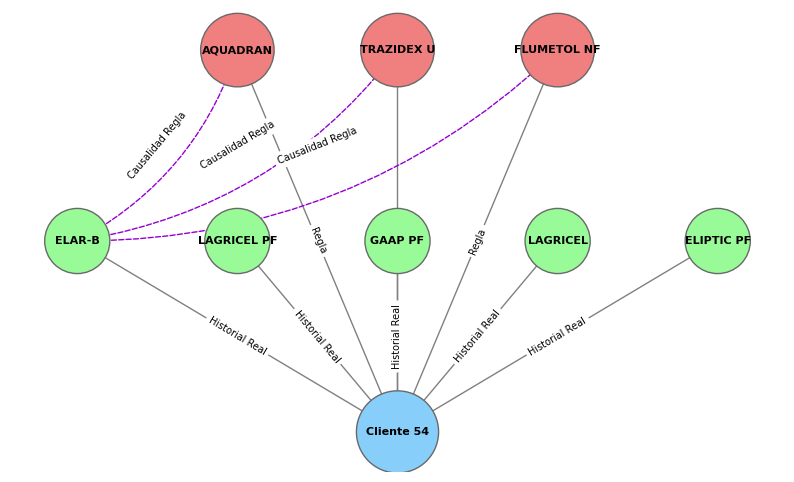

---

### 📅 Mes +1 (Próximo Mes)

,Fármaco,Vol. Sugerido,Proyección,Motor ML,Detonante
0,ZEBESTEN,12 unds.,$589.05,Regla de Asociación (Apriori),ELAR-B
1,SOPHIPREN,20 unds.,$847.00,Regla de Asociación (Apriori),ELIPTIC PF
2,LANDAX,16 unds.,$671.20,Regla de Asociación (Apriori),AGGLAD



🔎 Auditoría de Inteligencia Explicable (XAI):
➤ Fármaco: ZEBESTEN
   La recomendación se basa en una auditoría de la base de datos transaccional del cliente, la cual confirma un consumo consolidado del producto ancla 'ELAR-B'. Este patrón de consumo determinista ha activado una regla de asociación predefinida, que dispara la sugerencia del producto 'ZEBESTEN' con una Confianza del 50.0% y un Lift de 7.06. La trazabilidad de la propuesta se establece directamente desde el comportamiento transaccional actual del cliente hasta la aplicación de esta regla matemática de propensión.

Se sugiere una adquisición de 12 unidades de 'ZEBESTEN', valoradas en $589.05, fundamentada en la mediana de consumo del clúster al que pertenece este cliente. Proyectando un horizonte para el Mes +1, esta propuesta se formula bajo el supuesto de que la recomendación emitida en el mes actual fue aceptada y procesada, asegurando la continuidad y progresión estratégica en la oferta de valor.

➤ Fármaco: SOPHIPREN

#### 🗺️ Grafo Causal Multipartito (Caja de Cristal)

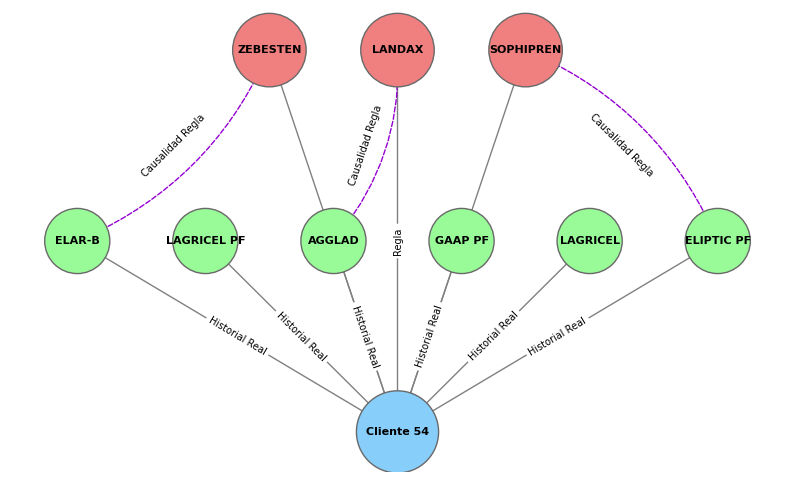

---

### 📅 Mes +2 (Proyección)

,Fármaco,Vol. Sugerido,Proyección,Motor ML,Detonante
0,SPLASH TEARS,10 unds.,$250.00,Contenido (Nuevo Lanzamiento),LAGRICEL



🔎 Auditoría de Inteligencia Explicable (XAI):
➤ Fármaco: SPLASH TEARS
   El ítem identificado se deriva de un análisis riguroso utilizando la metodología de segmentación K-Means. Su selección se basa en ser el componente con la mayor rotación constante dentro de su clúster asignado, un criterio que asegura la relevancia operativa y la representatividad del producto dentro de su segmento de comportamiento homogéneo.

La recomendación financiera de 10 unidades, valoradas en $250.0, se justifica directamente por la mediana de consumo histórico del clúster asociado, garantizando una propuesta basada en el comportamiento típico de este segmento. Esta proyección se establece con un horizonte de Mes +2, un período que integra y consolida los patrones de consumo registrados en los meses previos, proporcionando una base sólida para la toma de decisiones futuras.



#### 🗺️ Grafo Causal Multipartito (Caja de Cristal)

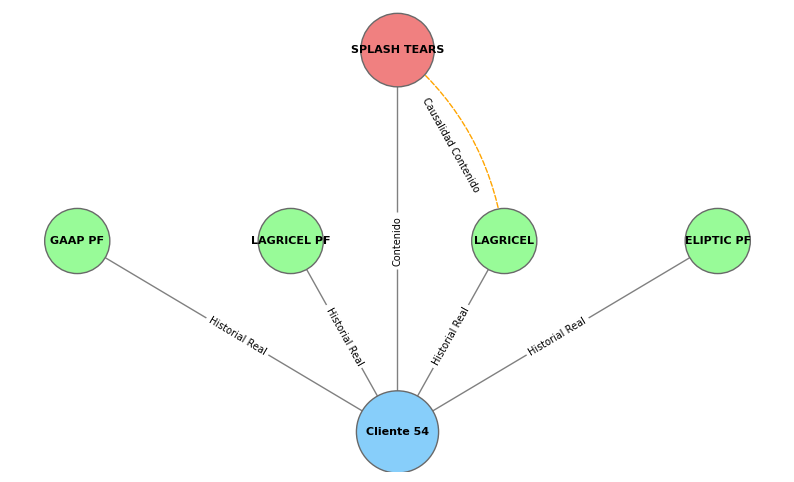

---

### 📈 Análisis Matemático de Tendencia (Regresión Polinomial)

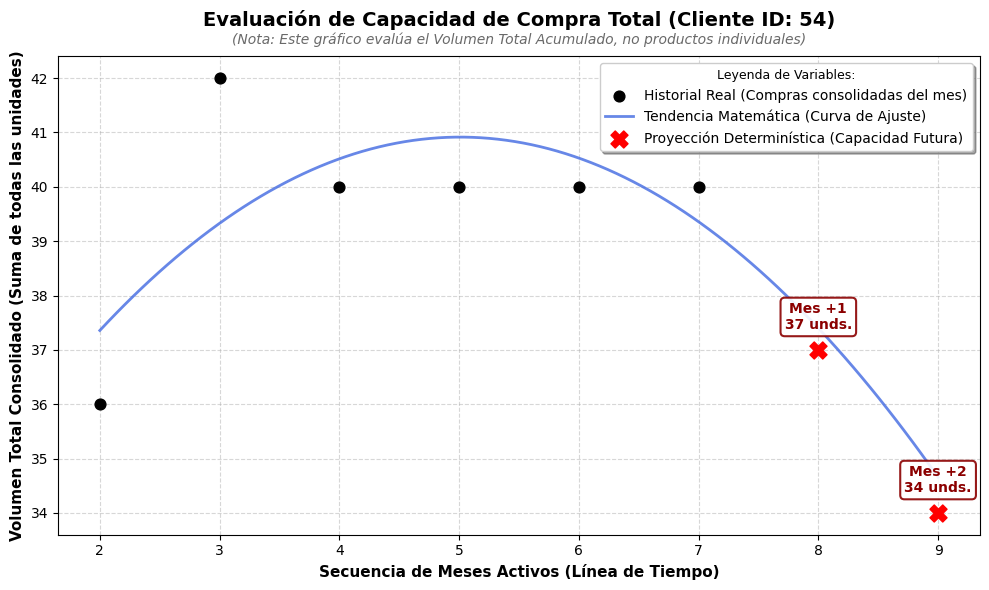

**Validación Matemática:** La curva extraída es $f(x) = -0.39x^2 + 3.94x + 31.06$. Al reemplazar la 'x' por el mes a proyectar, el sistema determina exactamente el tope de unidades sugeridas.

In [ ]:
# --- VARIABLES DE ENTRADA ---
ZONA_ACTIVA = "PHARMA - N2"
CLIENTE_SELECCIONADO = 54

display(Markdown(f"## 🚀 Diagnóstico B2B - Proyección a 3 Meses (Cliente ID: {CLIENTE_SELECCIONADO})"))
display(Markdown("---"))

df_filtrado = compras_ctx[compras_ctx[col_zona] == ZONA_ACTIVA] if col_zona else compras_ctx
historial_ids_reales = df_filtrado[df_filtrado['cliente_id'] == CLIENTE_SELECCIONADO]['producto_id'].tolist()
historial_nombres_reales = [mapa_productos.get(pid, pid) for pid in historial_ids_reales]

df_cliente_actual = df_filtrado[df_filtrado['cliente_id'] == CLIENTE_SELECCIONADO]
top_detonadores = df_cliente_actual.groupby('producto')['cantidad'].sum().nlargest(5).index.tolist()
if not top_detonadores: top_detonadores = historial_nombres_reales.copy()

cluster_cliente = cluster_dict.get(CLIENTE_SELECCIONADO, 0)
horizonte_meses = ["Mes Actual (En Curso)", "Mes +1 (Próximo Mes)", "Mes +2 (Proyección)"]
proyecciones_por_mes = {}

historial_simulado = historial_nombres_reales.copy()
detonadores_simulados = top_detonadores.copy()
nombres_recomendados_trimestre = set()
bases_recomendadas_trimestre = set()

try:
    from content_recommender import MotorContenido, inyectar_candidatos_nuevos
    motor_contenido = MotorContenido(compras_ctx)
except Exception as e:
    motor_contenido = None

# =====================================================================
# --- CONEXIÓN DE ARQUITECTURA: PRE-CÁLCULO POLINOMIAL ---
# =====================================================================
limites_polinomiales = {}
tendencia_mensual = None
if 'mes' in df_cliente_actual.columns and len(df_cliente_actual) > 0:
    tendencia_mensual = df_cliente_actual.groupby('mes')['cantidad'].sum().reset_index()
    if len(tendencia_mensual) >= 3:
        x_hist = tendencia_mensual['mes'].values
        y_hist = tendencia_mensual['cantidad'].values
        coeficientes = np.polyfit(x_hist, y_hist, 2)
        polinomio = np.poly1d(coeficientes)

        ultimo_mes_real = x_hist.max()
        limites_polinomiales["Mes Actual (En Curso)"] = max(0, int(polinomio(ultimo_mes_real)))
        limites_polinomiales["Mes +1 (Próximo Mes)"] = max(0, int(polinomio(ultimo_mes_real + 1)))
        limites_polinomiales["Mes +2 (Proyección)"] = max(0, int(polinomio(ultimo_mes_real + 2)))

# PROCESAMIENTO
for paso, mes_nombre in enumerate(horizonte_meses):
    candidatos = []

    # 1. APRIORI
    if not reglas_asociacion.empty:
        set_detonadores = set(detonadores_simulados)
        reglas_aplicables = reglas_asociacion[reglas_asociacion['antecedents'].apply(lambda x: set(x).issubset(set_detonadores))]

        for _, regla in reglas_aplicables.iterrows():
            antecedentes = sorted(list(regla['antecedents']))
            consecuentes = list(regla['consequents'])
            confianza_pct = round(regla['confidence'] * 100, 1)
            lift_val      = round(regla['lift'], 2)

            for prod_consecuente in consecuentes:
                if prod_consecuente not in historial_simulado:
                    candidatos.append({
                        "prod": prod_consecuente, "motor": "Regla de Asociación (Apriori)",
                        "score": regla['lift'], "confianza": confianza_pct, "lift": lift_val, "detonante": antecedentes[0]
                    })

    # 2. K-MEANS
    if len(candidatos) < 3:
        clientes_mismo_cluster = [cid for cid, clus in cluster_dict.items() if clus == cluster_cliente]
        df_cluster = compras_ctx[compras_ctx['cliente_id'].isin(clientes_mismo_cluster)]
        for prod_cluster in df_cluster['producto'].value_counts().index.tolist():
            if prod_cluster not in historial_simulado:
                candidatos.append({"prod": prod_cluster, "motor": "Cluster K-Means", "score": 1.0, "confianza": "N/A", "lift": "N/A", "detonante": "Perfil K-Means"})

    # 3. CONTENIDO (Para rescate)
    if motor_contenido and hasattr(motor_contenido, 'hay_productos_nuevos') and motor_contenido.hay_productos_nuevos():
        mapa_inv = {v.upper(): k for k, v in mapa_productos.items()}
        try:
            candidatos_nuevos = inyectar_candidatos_nuevos(motor_contenido, historial_simulado, mapa_inv)
            for prod_id_n, motor_n, score_n, meta_n in candidatos_nuevos:
                nombre_n = prod_id_n.replace("NUEVO_", "") if isinstance(prod_id_n, str) else mapa_productos.get(prod_id_n, str(prod_id_n))
                candidatos.append({
                    "prod": nombre_n, "motor": motor_n, "score": score_n,
                    "confianza": f"{score_n*100:.1f}", "lift": "TF-IDF", "detonante": meta_n['similar_a']
                })
        except Exception:
            pass

    recomendaciones_mes = []
    candidatos.sort(key=lambda x: (-float(x["score"]), x["prod"]))

    for cand in candidatos:
        if len(recomendaciones_mes) >= 3: break

        prod_rec = cand["prod"]
        base_prod = prod_rec.replace(' PF', '').replace(' PLUS', '').replace(' U', '').replace(' O', '').strip()
        if prod_rec in nombres_recomendados_trimestre or base_prod in bases_recomendadas_trimestre: continue

        seguro, _ = pasa_filtros_seguridad(prod_rec, historial_simulado, ZONA_ACTIVA, cand["motor"], compras_ctx, col_zona)
        if seguro:
            # 1. Volumen Teórico (K-Means)
            if (cluster_cliente, prod_rec) in volumenes_cluster:
                vol_kmeans = int(volumenes_cluster[(cluster_cliente, prod_rec)])
            else:
                med_global = compras_ctx[compras_ctx['producto'] == prod_rec]['cantidad'].median()
                vol_kmeans = int(med_global) if not pd.isna(med_global) else 10

            # 2. Regla de Determinismo Híbrido (K-Means vs Regresión)
            if mes_nombre in limites_polinomiales:
                tope_tendencia = limites_polinomiales[mes_nombre]

                # Freno B2B: Evitar canibalización o sobre-stock
                if tope_tendencia <= 0:
                    continue

                cant_sug = min(vol_kmeans, tope_tendencia)
            else:
                cant_sug = vol_kmeans

            precio_u = precios_dict.get(prod_rec)
            if pd.isna(precio_u) or precio_u is None: precio_u = 25.00
            ingreso_est = round(cant_sug * float(precio_u), 2)

            es_historico_bool = cand["detonante"] in historial_nombres_reales
            exp_xai = generar_explicacion_ml(prod_rec, historial_simulado, cand["motor"], mes_nombre, cant_sug, ingreso_est, cand["confianza"], cand["lift"], cand["detonante"], es_historico_bool)

            recomendaciones_mes.append({
                "Fármaco": prod_rec, "Vol. Sugerido": f"{cant_sug} unds.", "Proyección": f"${ingreso_est:,.2f}",
                "Motor ML": cand["motor"], "Detonante": cand["detonante"], "XAI Justificación": exp_xai
            })

            nombres_recomendados_trimestre.add(prod_rec)
            bases_recomendadas_trimestre.add(base_prod)
            historial_simulado.append(prod_rec)
            detonadores_simulados.append(prod_rec)

    proyecciones_por_mes[mes_nombre] = recomendaciones_mes

# =====================================================================
# VISUALIZACIÓN DE REPORTE Y GRAFO EN COLAB
# =====================================================================
for mes, recs in proyecciones_por_mes.items():
    display(Markdown(f"### 📅 {mes}"))
    if recs:
        df_mostrar = pd.DataFrame(recs).drop(columns=['XAI Justificación'])
        display(df_mostrar)
        print("\n🔎 Auditoría de Inteligencia Explicable (XAI):")
        for rec in recs:
            print(f"➤ Fármaco: {rec['Fármaco']}\n   {rec['XAI Justificación']}\n")

        display(Markdown("#### 🗺️ Grafo Causal Multipartito (Caja de Cristal)"))
        G = nx.DiGraph()
        nodo_cliente = f"Cliente {CLIENTE_SELECCIONADO}"
        G.add_node(nodo_cliente, color='#87CEFA', size=3500, layer=0)

        items_a_mostrar = set(historial_nombres_reales[-5:])
        for rec in recs:
            if rec['Detonante'] != "Perfil K-Means": items_a_mostrar.add(rec['Detonante'])

        for item in items_a_mostrar:
            if item in historial_nombres_reales:
                G.add_node(item, color='#98FB98', size=2200, layer=1)
                G.add_edge(nodo_cliente, item, label="Historial Real", style='solid', color='gray')
            else:
                G.add_node(item, color='#FFD700', size=2200, layer=1)
                G.add_edge(nodo_cliente, item, label="Cascada Previa", style='dotted', color='orange')

        for rec in recs:
            prod = rec['Fármaco']
            G.add_node(prod, color='#F08080', size=2800, layer=2)
            G.add_edge(nodo_cliente, prod, label=rec['Motor ML'].split(' ')[0], style='solid', color='gray')

            if rec['Detonante'] in items_a_mostrar:
                c_arista = "darkviolet" if "Apriori" in rec['Motor ML'] else ("tomato" if "TF-IDF" in rec['Motor ML'] else "orange")
                G.add_edge(rec['Detonante'], prod, label=f"Causalidad {rec['Motor ML'].split(' ')[0]}", style='dashed', color=c_arista)

        fig, ax = plt.subplots(figsize=(10, 6))
        pos = nx.multipartite_layout(G, subset_key="layer", align="horizontal")
        nx.draw_networkx_nodes(G, pos, node_color=[n[1]['color'] for n in G.nodes(data=True)], node_size=[n[1]['size'] for n in G.nodes(data=True)], edgecolors='dimgray', ax=ax)
        nx.draw_networkx_labels(G, pos, font_size=8, font_weight="bold", ax=ax)

        aristas_solidas = [(u, v) for u, v, d in G.edges(data=True) if d['style'] == 'solid']
        aristas_punteadas = [(u, v) for u, v, d in G.edges(data=True) if d['style'] in ['dashed', 'dotted']]

        nx.draw_networkx_edges(G, pos, edgelist=aristas_solidas, edge_color="gray", arrows=True, ax=ax)
        nx.draw_networkx_edges(G, pos, edgelist=aristas_punteadas, edge_color=[G[u][v]['color'] for u, v in aristas_punteadas], style="dashed", connectionstyle="arc3,rad=0.2", ax=ax)
        nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, 'label'), font_size=7, ax=ax)
        ax.axis('off')
        plt.show()
    else:
        print("No hay recomendaciones seguras para este periodo (Filtros de canibalización activos).\n")
    display(Markdown("---"))

# =====================================================================
# RENDERIZADO DEL GRÁFICO POLINOMIAL EN COLAB
# =====================================================================
display(Markdown("### 📈 Análisis Matemático de Tendencia (Regresión Polinomial)"))
if tendencia_mensual is not None and len(tendencia_mensual) >= 3:
    x_curva = np.linspace(x_hist.min(), x_hist.max() + 2, 100)
    y_curva = polinomio(x_curva)

    mes_futuro_1 = x_hist.max() + 1
    mes_futuro_2 = x_hist.max() + 2
    y_futuro_1 = max(0, int(polinomio(mes_futuro_1)))
    y_futuro_2 = max(0, int(polinomio(mes_futuro_2)))

    fig_poly, ax_poly = plt.subplots(figsize=(10, 6))
    ax_poly.scatter(x_hist, y_hist, color='black', s=60, label='Historial Real (Compras consolidadas del mes)', zorder=5)
    ax_poly.plot(x_curva, y_curva, color='royalblue', linestyle='-', linewidth=2, label='Tendencia Matemática (Curva de Ajuste)', alpha=0.8)
    ax_poly.scatter([mes_futuro_1, mes_futuro_2], [y_futuro_1, y_futuro_2], color='red', marker='X', s=150, label='Proyección Determinística (Capacidad Futura)', zorder=6)

    bbox_props = dict(boxstyle="round,pad=0.3", fc="white", ec="darkred", lw=1.5, alpha=0.9)
    ax_poly.annotate(f"Mes +1\n{y_futuro_1} unds.", (mes_futuro_1, y_futuro_1),
                     textcoords="offset points", xytext=(0,15), ha='center', color='darkred', fontweight='bold', bbox=bbox_props)
    ax_poly.annotate(f"Mes +2\n{y_futuro_2} unds.", (mes_futuro_2, y_futuro_2),
                     textcoords="offset points", xytext=(0,15), ha='center', color='darkred', fontweight='bold', bbox=bbox_props)

    ax_poly.set_title(f"Evaluación de Capacidad de Compra Total (Cliente ID: {CLIENTE_SELECCIONADO})\n", fontsize=14, fontweight='bold')
    ax_poly.text(0.5, 1.02, "(Nota: Este gráfico evalúa el Volumen Total Acumulado, no productos individuales)",
                 horizontalalignment='center', verticalalignment='bottom', transform=ax_poly.transAxes, fontsize=10, color='dimgray', style='italic')

    ax_poly.set_xlabel("Secuencia de Meses Activos (Línea de Tiempo)", fontsize=11, fontweight='bold')
    ax_poly.set_ylabel("Volumen Total Consolidado (Suma de todas las unidades)", fontsize=11, fontweight='bold')
    ax_poly.legend(loc='upper right', frameon=True, shadow=True, title="Leyenda de Variables:", title_fontsize='9')
    ax_poly.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

    display(Markdown(f"**Validación Matemática:** La curva extraída es $f(x) = {coeficientes[0]:.2f}x^2 + {coeficientes[1]:.2f}x + {coeficientes[2]:.2f}$. Al reemplazar la 'x' por el mes a proyectar, el sistema determina exactamente el tope de unidades sugeridas."))
else:
    print("El cliente no cuenta con suficientes meses históricos (mínimo 3) para calcular una curva de regresión no lineal estadísticamente válida.")

## 🕸️ Topología de Recomendación (Reglas de Asociación y Similitud)

Este grafo de fuerza dirigida explica visualmente **qué detonó cada recomendación**. El cliente se ubica en el núcleo, orbitado por su historial de compras reales. Los nodos externos representan los fármacos sugeridos, los cuales son 'atraídos' matemáticamente hacia el producto histórico que disparó la regla de Apriori o la similitud de TF-IDF.

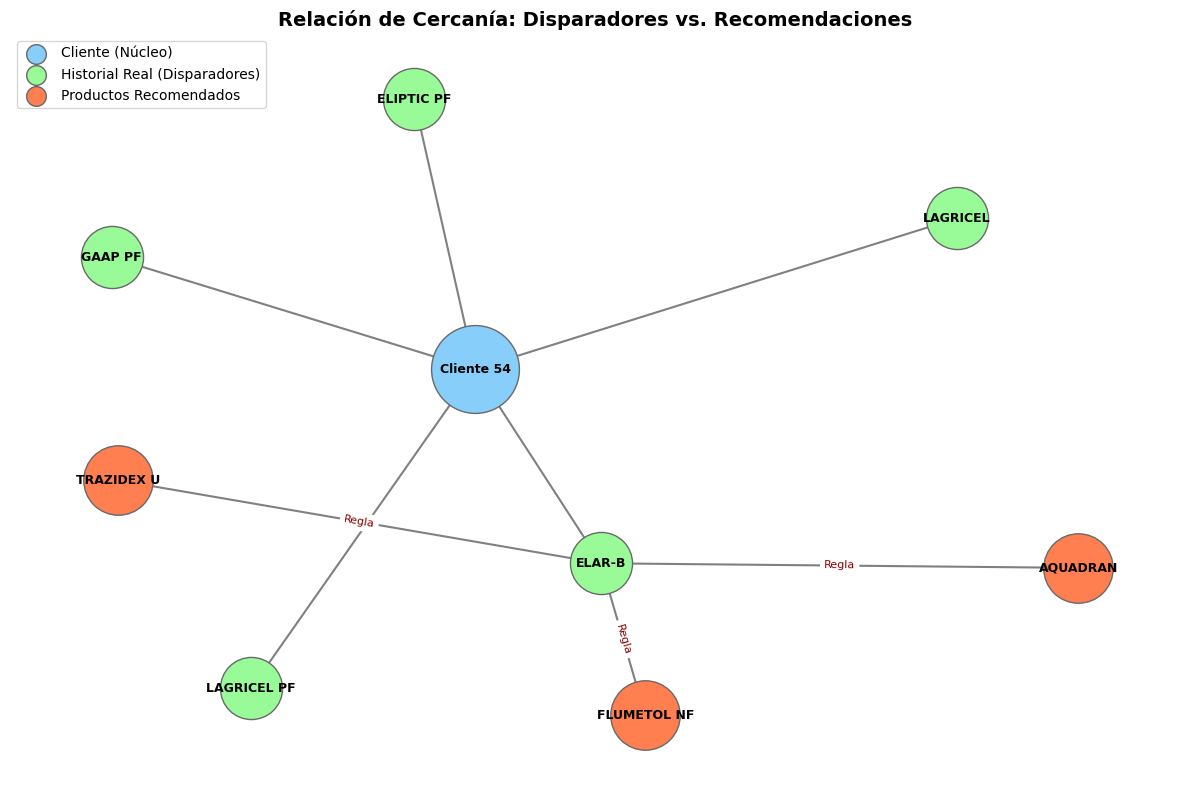

In [ ]:
# =====================================================================
# CELDA 8: GRAFO RADIAL DE CAUSALIDAD (APRIORI & TF-IDF)
# =====================================================================
import networkx as nx
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

display(Markdown("## 🕸️ Topología de Recomendación (Reglas de Asociación y Similitud)"))
display(Markdown("Este grafo de fuerza dirigida explica visualmente **qué detonó cada recomendación**. El cliente se ubica en el núcleo, orbitado por su historial de compras reales. Los nodos externos representan los fármacos sugeridos, los cuales son 'atraídos' matemáticamente hacia el producto histórico que disparó la regla de Apriori o la similitud de TF-IDF."))

# Extraemos las proyecciones del mes actual
recs_mes_actual = proyecciones_por_mes.get("Mes Actual (En Curso)", [])

if not recs_mes_actual:
    print("No hay recomendaciones para graficar en este periodo.")
else:
    G_radial = nx.DiGraph()
    nodo_cliente = f"Cliente {CLIENTE_SELECCIONADO}"

    # 1. Nodo Central (Cliente)
    G_radial.add_node(nodo_cliente, tipo='cliente')

    # 2. Construimos el Historial (Órbita Interna)
    # Filtramos para no saturar el gráfico, mostrando los recientes y los detonantes
    historial_a_mostrar = set(historial_nombres_reales[-6:])
    for rec in recs_mes_actual:
        if rec['Detonante'] != "Perfil K-Means":
            historial_a_mostrar.add(rec['Detonante'])

    for prod in historial_a_mostrar:
        G_radial.add_node(prod, tipo='historial')
        # Arista fuerte para mantenerlos cerca del centro
        G_radial.add_edge(nodo_cliente, prod, weight=4)

    # 3. Construimos las Recomendaciones (Órbita Externa)
    for rec in recs_mes_actual:
        prod_rec = rec['Fármaco']
        detonante = rec['Detonante']
        motor = rec['Motor ML'].split(' ')[0] # Extrae "Apriori" o "TF-IDF"

        G_radial.add_node(prod_rec, tipo='recomendacion')

        if detonante in G_radial.nodes:
            # Si hay detonante, lo conectamos a su producto histórico (La "cercanía" que pidió el asesor)
            G_radial.add_edge(detonante, prod_rec, label=motor, weight=2)
        else:
            # Fallback en caso de que sea una sugerencia general
            G_radial.add_edge(nodo_cliente, prod_rec, label=motor, weight=1)

    # --- DIBUJADO DEL GRAFO RADIAL ---
    fig, ax = plt.subplots(figsize=(12, 8))

    # El layout 'spring' simula resortes. Los nodos conectados se atraen, los desconectados se repelen.
    # Esto genera exactamente el efecto "puntos cercanos" que describiste.
    pos = nx.spring_layout(G_radial, k=0.6, seed=42)

    # Clasificación de nodos para darles color
    nodos_cli = [n for n, d in G_radial.nodes(data=True) if d.get('tipo') == 'cliente']
    nodos_his = [n for n, d in G_radial.nodes(data=True) if d.get('tipo') == 'historial']
    nodos_rec = [n for n, d in G_radial.nodes(data=True) if d.get('tipo') == 'recomendacion']

    # Dibujamos las 3 capas (Centro -> Historial -> Recomendado)
    nx.draw_networkx_nodes(G_radial, pos, nodelist=nodos_cli, node_color='#87CEFA', node_size=4000, edgecolors='dimgray', ax=ax)
    nx.draw_networkx_nodes(G_radial, pos, nodelist=nodos_his, node_color='#98FB98', node_size=2000, edgecolors='dimgray', ax=ax)
    nx.draw_networkx_nodes(G_radial, pos, nodelist=nodos_rec, node_color='#FF7F50', node_size=2500, edgecolors='dimgray', ax=ax)

    # Dibujamos las aristas y etiquetas
    nx.draw_networkx_edges(G_radial, pos, edge_color='gray', arrows=True, arrowsize=15, width=1.5, ax=ax)
    nx.draw_networkx_labels(G_radial, pos, font_size=9, font_weight='bold', ax=ax)

    # Etiquetas de las aristas (Para mostrar "Apriori" o "TF-IDF" entre el detonante y la sugerencia)
    edge_labels = nx.get_edge_attributes(G_radial, 'label')
    nx.draw_networkx_edge_labels(G_radial, pos, edge_labels=edge_labels, font_size=8, font_color='darkred', ax=ax)

    # Leyenda limpia
    ax.scatter([],[], c='#87CEFA', s=200, label='Cliente (Núcleo)', edgecolors='dimgray')
    ax.scatter([],[], c='#98FB98', s=200, label='Historial Real (Disparadores)', edgecolors='dimgray')
    ax.scatter([],[], c='#FF7F50', s=200, label='Productos Recomendados', edgecolors='dimgray')
    ax.legend(loc='upper left', fontsize=10, frameon=True)

    ax.set_title("Relación de Cercanía: Disparadores vs. Recomendaciones", fontsize=14, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

## 🪐 Sistema Solar de Recomendaciones (Causalidad Exacta)

Este diseño orbital sitúa al cliente en el núcleo `(0,0)`. El primer anillo (verde) contiene su historial real distribuido trigonométricamente. El segundo anillo (naranja) proyecta los productos recomendados en el mismo vector angular que su producto disparador, demostrando visualmente la regla de asociación Apriori.

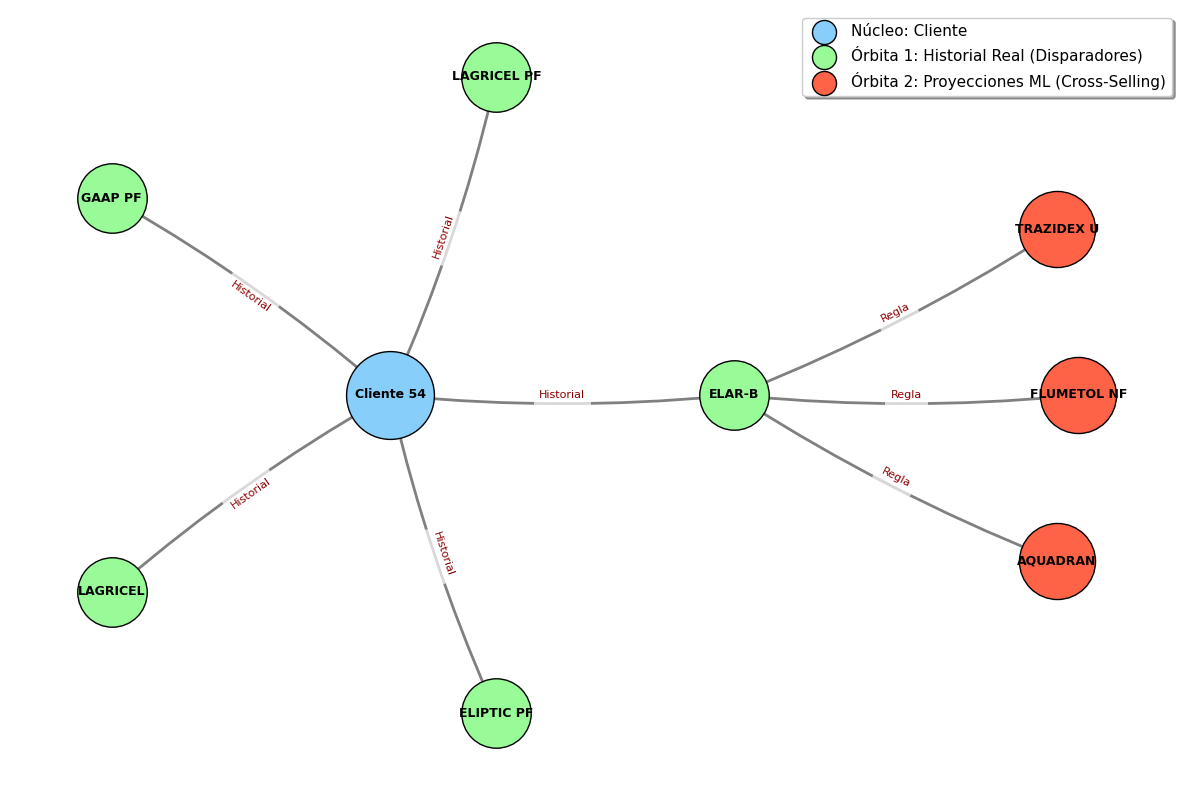

In [ ]:
# =====================================================================
# NUEVA CELDA: GRAFO ORBITAL DE CAUSALIDAD (TOPOLOGÍA MATEMÁTICA)
# =====================================================================
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, Markdown

display(Markdown("## 🪐 Sistema Solar de Recomendaciones (Causalidad Exacta)"))
display(Markdown("Este diseño orbital sitúa al cliente en el núcleo `(0,0)`. El primer anillo (verde) contiene su historial real distribuido trigonométricamente. El segundo anillo (naranja) proyecta los productos recomendados en el mismo vector angular que su producto disparador, demostrando visualmente la regla de asociación Apriori."))

recs_mes_actual = proyecciones_por_mes.get("Mes Actual (En Curso)", [])

if not recs_mes_actual:
    print("No hay recomendaciones seguras para el Mes Actual que graficar.")
else:
    G_orbital = nx.DiGraph()
    nodo_cliente = f"Cliente {CLIENTE_SELECCIONADO}"
    G_orbital.add_node(nodo_cliente, tipo='cliente')

    # 1. Recopilar historial relevante (Máximo 6 para no saturar el anillo)
    historial_a_mostrar = set(historial_nombres_reales[-6:])
    for rec in recs_mes_actual:
        if rec['Detonante'] != "Perfil K-Means":
            historial_a_mostrar.add(rec['Detonante'])
    historial_list = list(historial_a_mostrar)

    # 2. Agregar nodos y aristas de historial
    for prod in historial_list:
        G_orbital.add_node(prod, tipo='historial')
        G_orbital.add_edge(nodo_cliente, prod, label="Historial")

    # 3. Agregar nodos de recomendación
    recs_list = []
    for rec in recs_mes_actual:
        prod_rec = rec['Fármaco']
        detonante = rec['Detonante']
        motor = rec['Motor ML'].split(' ')[0]

        G_orbital.add_node(prod_rec, tipo='recomendacion')
        if detonante in G_orbital.nodes:
            G_orbital.add_edge(detonante, prod_rec, label=motor)
        else:
            G_orbital.add_edge(nodo_cliente, prod_rec, label=motor)
        recs_list.append((prod_rec, detonante))

    # =================================================================
    # MOTOR TRIGONOMÉTRICO DE POSICIONAMIENTO
    # =================================================================
    pos = {nodo_cliente: np.array([0.0, 0.0])} # Núcleo

    R1 = 2.0 # Radio del Anillo Histórico
    R2 = 4.0 # Radio del Anillo de Recomendaciones

    num_hist = len(historial_list)
    angles = np.linspace(0, 2 * np.pi, num_hist, endpoint=False)

    # Asignar coordenadas (x, y) al anillo histórico
    hist_angles = {}
    for i, prod in enumerate(historial_list):
        theta = angles[i]
        hist_angles[prod] = theta
        pos[prod] = np.array([R1 * np.cos(theta), R1 * np.sin(theta)])

    # Asignar coordenadas (x, y) a las recomendaciones (alineadas a su detonante)
    from collections import defaultdict
    det_to_recs = defaultdict(list)
    for rec_prod, det in recs_list:
        det_to_recs[det].append(rec_prod)

    for det, r_list in det_to_recs.items():
        if det in hist_angles:
            base_theta = hist_angles[det]
            # Si un disparador tiene múltiples recomendaciones, las separamos un poquito
            spread = 0.25
            offsets = [0] if len(r_list) == 1 else np.linspace(-spread, spread, len(r_list))

            for offset, rec_prod in zip(offsets, r_list):
                t = base_theta + offset
                pos[rec_prod] = np.array([R2 * np.cos(t), R2 * np.sin(t)])
        else:
            # Fallback de K-Means (va directo arriba)
            pos[rec_prod] = np.array([0.0, R2])

    # =================================================================
    # RENDERIZADO VISUAL PROFESIONAL
    # =================================================================
    fig, ax = plt.subplots(figsize=(12, 8))

    nodos_cli = [n for n, d in G_orbital.nodes(data=True) if d.get('tipo') == 'cliente']
    nodos_his = [n for n, d in G_orbital.nodes(data=True) if d.get('tipo') == 'historial']
    nodos_rec = [n for n, d in G_orbital.nodes(data=True) if d.get('tipo') == 'recomendacion']

    # Dibujar nodos
    nx.draw_networkx_nodes(G_orbital, pos, nodelist=nodos_cli, node_color='#87CEFA', node_size=4000, edgecolors='black', ax=ax)
    nx.draw_networkx_nodes(G_orbital, pos, nodelist=nodos_his, node_color='#98FB98', node_size=2500, edgecolors='black', ax=ax)
    nx.draw_networkx_nodes(G_orbital, pos, nodelist=nodos_rec, node_color='#FF6347', node_size=3000, edgecolors='black', ax=ax)

    # Dibujar aristas con flechas curvas elegantes
    nx.draw_networkx_edges(G_orbital, pos, edge_color='gray', arrows=True, arrowsize=20, width=2.0, connectionstyle="arc3,rad=0.05", ax=ax)

    # Dibujar etiquetas de los nodos (Nombres de productos)
    nx.draw_networkx_labels(G_orbital, pos, font_size=9, font_weight='bold', ax=ax)

    # Dibujar etiquetas de las aristas (La regla: "Apriori" o "Historial")
    edge_labels = nx.get_edge_attributes(G_orbital, 'label')
    nx.draw_networkx_edge_labels(G_orbital, pos, edge_labels=edge_labels, font_size=8, font_color='darkred',
                                 bbox=dict(facecolor='white', edgecolor='none', alpha=0.7), ax=ax)

    # Limpiar ejes y hacer que el gráfico ocupe todo el espacio
    ax.axis('off')

    # Leyenda para el asesor
    ax.scatter([],[], c='#87CEFA', s=300, label='Núcleo: Cliente', edgecolors='black')
    ax.scatter([],[], c='#98FB98', s=300, label='Órbita 1: Historial Real (Disparadores)', edgecolors='black')
    ax.scatter([],[], c='#FF6347', s=300, label='Órbita 2: Proyecciones ML (Cross-Selling)', edgecolors='black')
    ax.legend(loc='upper right', fontsize=11, frameon=True, shadow=True)

    plt.tight_layout()
    plt.show()

## 🔍 Lupa de Causalidad (Transparencia del Algoritmo)

Este grafo aísla el ruido del perfil del cliente y muestra exclusivamente las conexiones matemáticas directas. Reemplaza la etiqueta genérica 'Regla' por las métricas reales calculadas por la Inteligencia Artificial, detallando **exactamente qué evaluó el algoritmo** para trazar la conexión.

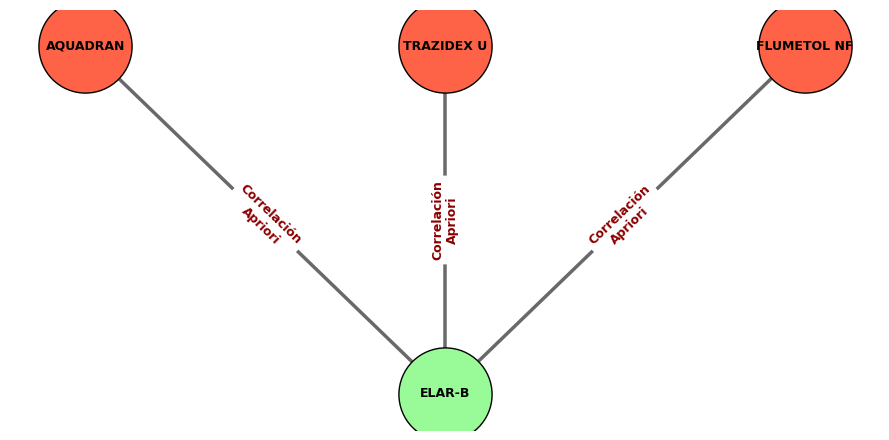

### 📊 Desglose de Evaluación Algorítmica: ¿Qué tomó en cuenta el sistema?

* **Regla Detectada:** `ELAR-B` $\rightarrow$ `AQUADRAN`

  * Patrón de compra conjunta validado estadísticamente en la canasta nacional.

* **Regla Detectada:** `ELAR-B` $\rightarrow$ `FLUMETOL NF`

  * Patrón de compra conjunta validado estadísticamente en la canasta nacional.

* **Regla Detectada:** `ELAR-B` $\rightarrow$ `TRAZIDEX U`

  * Patrón de compra conjunta validado estadísticamente en la canasta nacional.

In [ ]:
# =====================================================================
# CELDA 9: LUPA DE CAUSALIDAD (EXPLICABILIDAD MATEMÁTICA DE LA REGLA)
# =====================================================================
import networkx as nx
import matplotlib.pyplot as plt
import re
from IPython.display import display, Markdown

display(Markdown("## 🔍 Lupa de Causalidad (Transparencia del Algoritmo)"))
display(Markdown("Este grafo aísla el ruido del perfil del cliente y muestra exclusivamente las conexiones matemáticas directas. Reemplaza la etiqueta genérica 'Regla' por las métricas reales calculadas por la Inteligencia Artificial, detallando **exactamente qué evaluó el algoritmo** para trazar la conexión."))

recs_mes_actual = proyecciones_por_mes.get("Mes Actual (En Curso)", [])
# Filtramos solo las recomendaciones que nacen de un producto ancla
recs_reglas = [rec for rec in recs_mes_actual if "Apriori" in rec['Motor ML'] or "TF-IDF" in rec['Motor ML']]

if not recs_reglas:
    print("No hay reglas de asociación Producto-a-Producto activas para aislar en este periodo.")
else:
    G_aislado = nx.DiGraph()
    detalles_reglas = []

    for rec in recs_reglas:
        detonante = rec['Detonante']
        sugerencia = rec['Fármaco']
        motor = rec['Motor ML']

        # Capas para alinear el grafo: 0 (Izquierda/Ancla) -> 1 (Derecha/Sugerencia)
        G_aislado.add_node(detonante, tipo='detonante', layer=0)
        G_aislado.add_node(sugerencia, tipo='sugerencia', layer=1)

        label_arista = "Regla"
        explicacion_matematica = ""

        # Extraemos dinámicamente la Confianza y el Lift de la justificación
        if 'Apriori' in motor:
            match = re.search(r'Confianza:\s*([\d.]+)%?.*?Lift:\s*([\d.]+)', rec['XAI Justificación'], re.IGNORECASE)
            if match:
                conf, lift = match.groups()
                label_arista = f"Lift: {lift}\nConfianza: {conf}%"
                explicacion_matematica = (
                    f"**Lift de {lift}:** La presencia de `{detonante}` en la canasta "
                    f"multiplica por {lift} veces la probabilidad matemática de que compren `{sugerencia}`.\n"
                    f"**Confianza del {conf}%:** Del total histórico de clínicas que compran `{detonante}`, "
                    f"el {conf}% termina consolidando la compra conjunta con `{sugerencia}`."
                )
            else:
                label_arista = "Correlación\nApriori"
                explicacion_matematica = "Patrón de compra conjunta validado estadísticamente en la canasta nacional."
        elif 'TF-IDF' in motor:
            label_arista = "Afinidad\nTerapéutica"
            explicacion_matematica = f"Similitud calculada mediante Vectores TF-IDF. `{sugerencia}` es un producto nuevo (sin historial) cuya composición y subfamilia coinciden altamente con `{detonante}`."

        G_aislado.add_edge(detonante, sugerencia, label=label_arista)

        detalles_reglas.append({
            "Ancla": detonante,
            "Sugerencia": sugerencia,
            "Explicacion": explicacion_matematica
        })

    # Renderizado del grafo bipartito
    fig, ax = plt.subplots(figsize=(9, 4.5))

    pos = nx.multipartite_layout(G_aislado, subset_key="layer", align="vertical")
    pos_horizontal = {node: (coords[1], coords[0]) for node, coords in pos.items()}

    nodos_det = [n for n, d in G_aislado.nodes(data=True) if d.get('tipo') == 'detonante']
    nodos_sug = [n for n, d in G_aislado.nodes(data=True) if d.get('tipo') == 'sugerencia']

    nx.draw_networkx_nodes(G_aislado, pos_horizontal, nodelist=nodos_det, node_color='#98FB98', node_size=4500, edgecolors='black', ax=ax)
    nx.draw_networkx_nodes(G_aislado, pos_horizontal, nodelist=nodos_sug, node_color='#FF6347', node_size=4500, edgecolors='black', ax=ax)

    nx.draw_networkx_edges(G_aislado, pos_horizontal, edge_color='dimgray', arrows=True, arrowsize=20, width=2.5, ax=ax)
    nx.draw_networkx_labels(G_aislado, pos_horizontal, font_size=9, font_weight='bold', ax=ax)

    # Inyectamos el Lift y la Confianza sobre las líneas
    edge_labels = nx.get_edge_attributes(G_aislado, 'label')
    nx.draw_networkx_edge_labels(G_aislado, pos_horizontal, edge_labels=edge_labels, font_color='darkred', font_weight='bold', font_size=9, ax=ax)

    ax.axis('off')
    plt.tight_layout()
    plt.show()

    # Impresión automática de los argumentos matemáticos para el jurado
    display(Markdown("### 📊 Desglose de Evaluación Algorítmica: ¿Qué tomó en cuenta el sistema?"))
    for d in detalles_reglas:
        display(Markdown(f"* **Regla Detectada:** `{d['Ancla']}` $\\rightarrow$ `{d['Sugerencia']}`"))
        display(Markdown(f"  * {d['Explicacion']}"))

## 📊 Análisis de Brechas: Cliente vs. Mercado Nacional

Este gráfico responde a la pregunta fundamental: **¿Qué está comprando el resto del país que este cliente no?** Compara la penetración de los fármacos a nivel nacional frente al catálogo actual del cliente, revelando los 'vacíos' comerciales (barras naranjas) que el algoritmo Apriori intenta llenar mediante sus reglas de asociación.

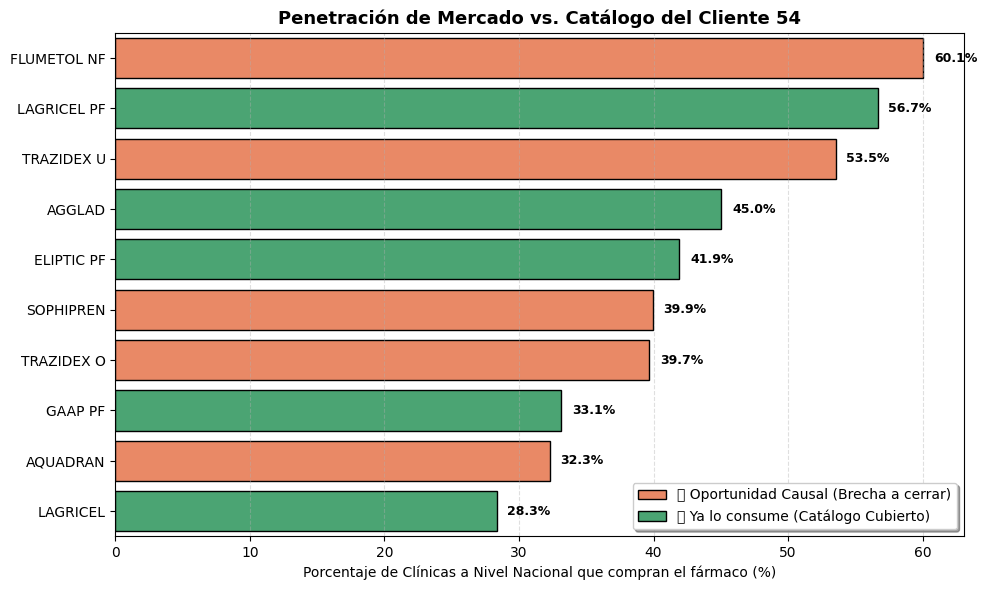

In [ ]:
# =====================================================================
# CELDA 10: ANÁLISIS DE BRECHAS (CLIENTE VS. CANASTA NACIONAL)
# =====================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

display(Markdown("## 📊 Análisis de Brechas: Cliente vs. Mercado Nacional"))
display(Markdown("Este gráfico responde a la pregunta fundamental: **¿Qué está comprando el resto del país que este cliente no?** Compara la penetración de los fármacos a nivel nacional frente al catálogo actual del cliente, revelando los 'vacíos' comerciales (barras naranjas) que el algoritmo Apriori intenta llenar mediante sus reglas de asociación."))

# 1. Calcular penetración nacional (Porcentaje de clientes únicos que compran cada producto)
total_clientes_nacional = compras_ctx['cliente_id'].nunique()
penetration = compras_ctx.groupby('producto')['cliente_id'].nunique() / total_clientes_nacional * 100
# Tomamos el Top 10 de productos más extendidos en el país
penetration = penetration.sort_values(ascending=False).head(10)

# 2. Identificar qué productos YA tiene el cliente evaluado
productos_cliente_actual = df_cliente_actual['producto'].unique()

# 3. Preparar los datos para cruzar ambas realidades
df_plot = pd.DataFrame({
    'Producto': penetration.index,
    'Penetración Nacional (%)': penetration.values
})

# Etiquetamos: Si el cliente ya lo tiene es "Cubierto", si no, es "Brecha"
df_plot['Estado en Cliente'] = df_plot['Producto'].apply(
    lambda x: '✅ Ya lo consume (Catálogo Cubierto)' if x in productos_cliente_actual else '🎯 Oportunidad Causal (Brecha a cerrar)'
)

# 4. Renderizado visual profesional
fig, ax = plt.subplots(figsize=(10, 6))

# Colores estratégicos: Verde para éxito, Naranja/Rojo para oportunidad de venta
colores = {
    '✅ Ya lo consume (Catálogo Cubierto)': 'mediumseagreen',
    '🎯 Oportunidad Causal (Brecha a cerrar)': 'coral'
}

sns.barplot(
    data=df_plot,
    y='Producto',
    x='Penetración Nacional (%)',
    hue='Estado en Cliente',
    palette=colores,
    dodge=False,
    ax=ax,
    edgecolor='black'
)

ax.set_title(f"Penetración de Mercado vs. Catálogo del Cliente {CLIENTE_SELECCIONADO}", fontsize=13, fontweight='bold')
ax.set_xlabel("Porcentaje de Clínicas a Nivel Nacional que compran el fármaco (%)", fontsize=10)
ax.set_ylabel("")

# Añadir el porcentaje exacto al lado de cada barra
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.text(width + 0.8, p.get_y() + p.get_height()/2., f'{width:.1f}%',
                va='center', fontsize=9, fontweight='bold')

# Ajustar la leyenda
ax.legend(loc='lower right', fontsize=10, frameon=True, shadow=True)
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## 📈 Matriz Estadística de Reglas de Asociación (Apriori)

Este gráfico de dispersión (*Bubble Chart*) visualiza el universo completo de patrones de compra cruzada descubiertos a nivel nacional. Nos permite auditar visualmente las 3 métricas clave del algoritmo:


* **Eje X (Soporte):** ¿Qué tan frecuente es esta combinación en todo el país? (Descartamos nichos muy raros).
* **Eje Y (Confianza):** Si compran el Producto A, ¿cuál es la probabilidad matemática de que también lleven el B?
* **Tamaño del punto (Lift):** La fuerza de la correlación. Un círculo más grande indica una dependencia comercial altísima (no es simple casualidad).


Los puntos resaltados en **rojo** representan las reglas específicas que el algoritmo activó para el portafolio de este cliente en particular.

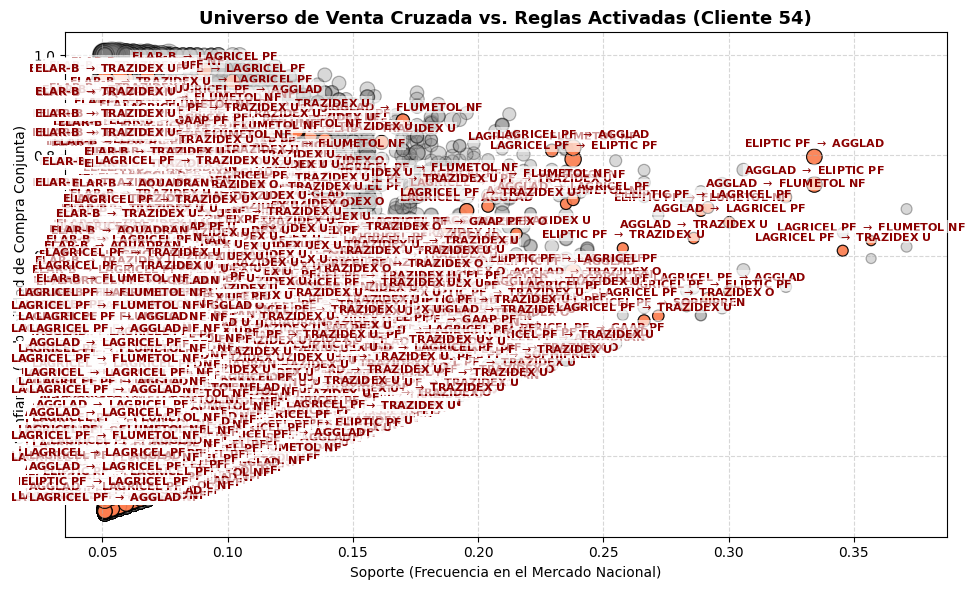

In [ ]:
# =====================================================================
# CELDA 11: MATRIZ DE EVALUACIÓN DE REGLAS (EL "CEREBRO" DE APRIORI)
# =====================================================================
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

display(Markdown("## 📈 Matriz Estadística de Reglas de Asociación (Apriori)"))
display(Markdown("Este gráfico de dispersión (*Bubble Chart*) visualiza el universo completo de patrones de compra cruzada descubiertos a nivel nacional. Nos permite auditar visualmente las 3 métricas clave del algoritmo:"))
display(Markdown("""
* **Eje X (Soporte):** ¿Qué tan frecuente es esta combinación en todo el país? (Descartamos nichos muy raros).
* **Eje Y (Confianza):** Si compran el Producto A, ¿cuál es la probabilidad matemática de que también lleven el B?
* **Tamaño del punto (Lift):** La fuerza de la correlación. Un círculo más grande indica una dependencia comercial altísima (no es simple casualidad).
"""))
display(Markdown("Los puntos resaltados en **rojo** representan las reglas específicas que el algoritmo activó para el portafolio de este cliente en particular."))

if reglas_asociacion.empty:
    print("No hay reglas de asociación generadas para visualizar. Revisa los hiperparámetros de Soporte y Lift.")
else:
    fig, ax = plt.subplots(figsize=(10, 6))

    # 1. Dibujamos TODO el universo de reglas (Fondo gris)
    sns.scatterplot(
        data=reglas_asociacion,
        x='support',
        y='confidence',
        size='lift',
        sizes=(50, 600),
        alpha=0.3,
        color='gray',
        edgecolor='black',
        legend=False,
        ax=ax
    )

    # 2. Identificamos las reglas que se activaron para nuestro cliente
    set_detonadores = set(top_detonadores)
    reglas_aplicables = reglas_asociacion[reglas_asociacion['antecedents'].apply(lambda x: set(x).issubset(set_detonadores))]

    # 3. Resaltamos las reglas del cliente (Rojo brillante)
    if not reglas_aplicables.empty:
        sns.scatterplot(
            data=reglas_aplicables,
            x='support',
            y='confidence',
            size='lift',
            sizes=(50, 600),
            alpha=0.9,
            color='coral',
            edgecolor='black',
            legend=False,
            ax=ax
        )

        # Añadimos etiquetas solo a las reglas del cliente para no saturar
        for _, row in reglas_aplicables.iterrows():
            ant = list(row['antecedents'])[0]
            con = list(row['consequents'])[0]
            label = f"{ant} $\\rightarrow$ {con}"

            ax.text(
                row['support'],
                row['confidence'] + 0.02,
                label,
                fontsize=8,
                fontweight='bold',
                color='darkred',
                ha='center',
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.6, pad=0.5)
            )

    ax.set_title(f"Universo de Venta Cruzada vs. Reglas Activadas (Cliente {CLIENTE_SELECCIONADO})", fontsize=13, fontweight='bold')
    ax.set_xlabel("Soporte (Frecuencia en el Mercado Nacional)", fontsize=10)
    ax.set_ylabel("Confianza (Probabilidad de Compra Conjunta)", fontsize=10)

    ax.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

In [ ]:
!pip install adjustText

## 📈 Auditoría de Venta Cruzada (Trazabilidad Apriori)


Este gráfico aísla y demuestra matemáticamente las reglas que justifican los **productos finales recomendados** al cliente en la cotización.

- **Gris:** Universo completo de reglas del mercado nacional.
- **Coral:** Reglas de Cross-Selling viables, pero descartadas o secundarias (Latentes).
- **Estrellas Rojas Numeradas:** Las reglas exactas que el motor seleccionó para la cotización de este mes.


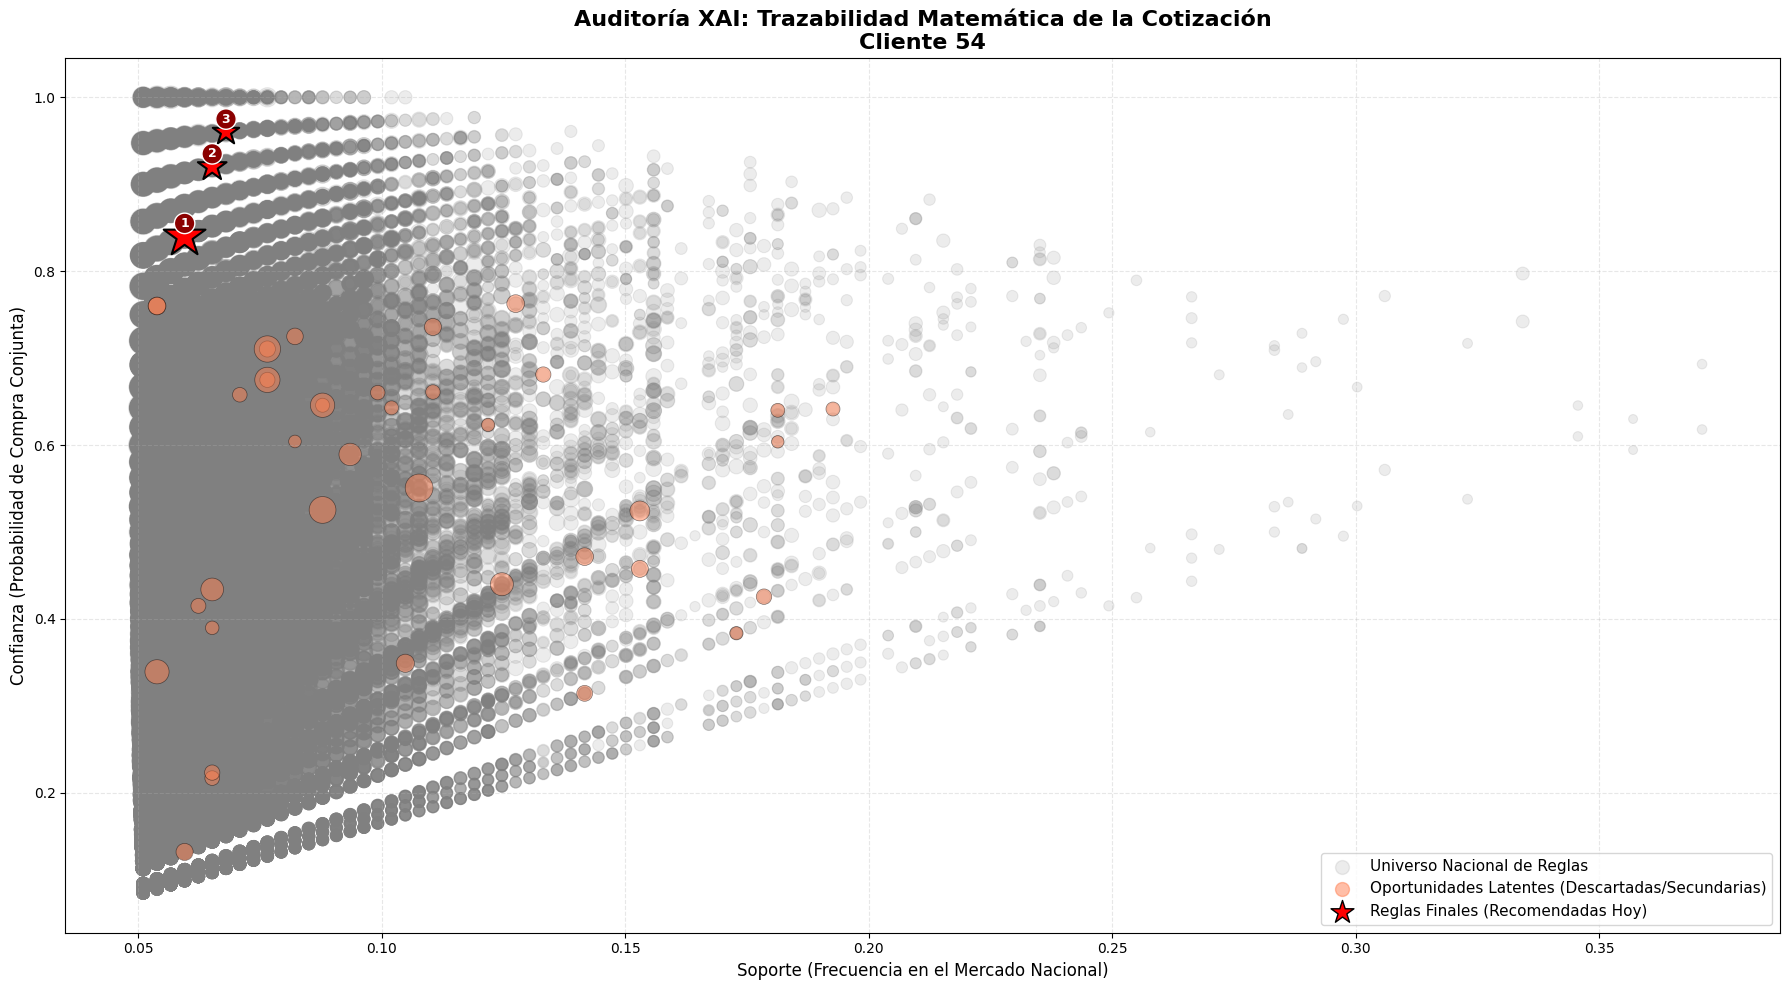

### 📋 Desglose de Reglas Finales Aplicadas en la Cotización Actual

,N°,Regla Algorítmica,Lift,Confianza,Soporte
0,1,"ELAR-B, LAGRICEL → AQUADRAN",2.60,0.84,0.059
1,2,"ELAR-B, LAGRICEL → TRAZIDEX U",1.72,0.92,0.065
2,3,"ELAR-B, LAGRICEL → FLUMETOL NF",1.60,0.96,0.068


In [ ]:
# =====================================================================
# CELDA 11: MATRIZ DE EVALUACIÓN DE REGLAS (AUDITORÍA DE COTIZACIÓN XAI)
# =====================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from IPython.display import display, Markdown

display(Markdown("## 📈 Auditoría de Venta Cruzada (Trazabilidad Apriori)"))

display(Markdown("""
Este gráfico aísla y demuestra matemáticamente las reglas que justifican los **productos finales recomendados** al cliente en la cotización.

- **Gris:** Universo completo de reglas del mercado nacional.
- **Coral:** Reglas de Cross-Selling viables, pero descartadas o secundarias (Latentes).
- **Estrellas Rojas Numeradas:** Las reglas exactas que el motor seleccionó para la cotización de este mes.
"""))

if reglas_asociacion.empty:
    print("No existen reglas de asociación.")
else:

    # ===============================================================
    # 1. Crear figura y graficar Universo Nacional (Gris)
    # ===============================================================
    fig, ax = plt.subplots(figsize=(18,10))

    sns.scatterplot(
        data=reglas_asociacion, x="support", y="confidence", size="lift", sizes=(40,450),
        color="gray", alpha=0.15, edgecolor=None, legend=False, ax=ax
    )

    # ===============================================================
    # 2. Filtrado de Reglas de Negocio (Cross-Selling)
    # ===============================================================
    set_detonadores = set(top_detonadores)
    historial_cliente = df_filtrado[df_filtrado['cliente_id'] == CLIENTE_SELECCIONADO]['producto'].unique().tolist()

    mask = []
    for idx, row in reglas_asociacion.iterrows():
        antecedente_valido = row["antecedents"].issubset(set_detonadores)
        # El consecuente NO debe estar en su historial (Cross-Selling puro)
        consecuente_nuevo = not any(c in historial_cliente for c in row["consequents"])
        mask.append(antecedente_valido and consecuente_nuevo)

    reglas_aplicables = reglas_asociacion[mask].copy()

    # Filtros estructurales de la regla
    reglas_aplicables['ant_len'] = reglas_aplicables['antecedents'].apply(len)
    reglas_aplicables['con_len'] = reglas_aplicables['consequents'].apply(len)

    reglas_aplicables = reglas_aplicables[
        (reglas_aplicables["lift"] >= 1.5) &
        (reglas_aplicables['ant_len'] <= 2) &
        (reglas_aplicables['con_len'] == 1) # Asegura reglas tácticas (1 sugerencia)
    ]

    # ===============================================================
    # 3. Sincronización con las Recomendaciones de la Celda 7
    # ===============================================================
    recs_mes_actual = proyecciones_por_mes.get("Mes Actual (En Curso)", [])
    # Extraemos qué fármacos recomendó realmente el algoritmo Apriori
    productos_recomendados = {rec['Fármaco'] for rec in recs_mes_actual if 'Apriori' in rec.get('Motor ML', 'Apriori')}

    # Separar las reglas latentes de las reglas finales elegidas
    mask_finales = reglas_aplicables['consequents'].apply(lambda c: list(c)[0] in productos_recomendados)

    reglas_latentes = reglas_aplicables[~mask_finales]
    reglas_finales = reglas_aplicables[mask_finales].sort_values(by=["lift", "confidence", "support"], ascending=False)

    # ===============================================================
    # 4. Renderizado de Puntos (Latentes vs. Finales)
    # ===============================================================

    # Ploteamos las reglas viables pero no elegidas (Coral)
    if not reglas_latentes.empty:
        sns.scatterplot(
            data=reglas_latentes, x="support", y="confidence", size="lift", sizes=(80,400),
            color="coral", edgecolor="black", linewidth=0.5, alpha=0.5, legend=False, ax=ax
        )

    tabla_reglas = []

    # Ploteamos EXCLUSIVAMENTE las reglas finales (Estrellas Rojas Numeradas)
    if not reglas_finales.empty:
        # Nos quedamos con la regla más fuerte (mayor Lift) para cada producto recomendado
        # Esto evita números duplicados si 2 reglas distintas sugieren el mismo producto
        reglas_finales_unicas = reglas_finales.drop_duplicates(subset=['consequents']).head(10)

        sns.scatterplot(
            data=reglas_finales_unicas, x="support", y="confidence", size="lift", sizes=(400,1000),
            color="red", marker="*", edgecolor="black", linewidth=1.5, alpha=1.0, legend=False, ax=ax, zorder=10
        )

        for i, (_, row) in enumerate(reglas_finales_unicas.iterrows(), start=1):

            # Etiqueta numérica
            ax.text(
                row["support"], row["confidence"] + 0.015, str(i),
                fontsize=9, color="white", fontweight="bold", ha="center", va="center",
                bbox=dict(boxstyle="circle", facecolor="darkred", edgecolor="white", pad=0.3), zorder=11
            )

            antecedente = ", ".join(sorted(row["antecedents"]))
            consecuente = ", ".join(sorted(row["consequents"]))

            tabla_reglas.append({
                "N°": i,
                "Regla Algorítmica": f"{antecedente} → {consecuente}",
                "Lift": round(row["lift"],2),
                "Confianza": round(row["confidence"],2),
                "Soporte": round(row["support"],3)
            })

    # ===============================================================
    # 5. Formato Final
    # ===============================================================
    ax.set_title(f"Auditoría XAI: Trazabilidad Matemática de la Cotización\nCliente {CLIENTE_SELECCIONADO}", fontsize=16, fontweight="bold")
    ax.set_xlabel("Soporte (Frecuencia en el Mercado Nacional)", fontsize=12)
    ax.set_ylabel("Confianza (Probabilidad de Compra Conjunta)", fontsize=12)
    ax.grid(True, linestyle="--", alpha=0.3)

    # Leyenda limpia
    ax.scatter([],[], c='gray', alpha=0.15, s=100, label='Universo Nacional de Reglas')
    ax.scatter([],[], c='coral', alpha=0.5, s=100, label='Oportunidades Latentes (Descartadas/Secundarias)')
    ax.scatter([],[], c='red', marker='*', s=300, edgecolor='black', label='Reglas Finales (Recomendadas Hoy)')
    ax.legend(loc='lower right', fontsize=11, frameon=True)

    plt.tight_layout()
    plt.show()

    # ===============================================================
    # 6. Mostrar tabla de reglas finales
    # ===============================================================
    if len(tabla_reglas) > 0:
        display(Markdown("### 📋 Desglose de Reglas Finales Aplicadas en la Cotización Actual"))
        display(pd.DataFrame(tabla_reglas))
    else:
        display(Markdown("*(Nota: El sistema no aplicó reglas Apriori para los productos de este periodo. Las recomendaciones podrían provenir del motor de Similitud TF-IDF).*"))

In [ ]:
# =====================================================================
# CELDA 12: EXPLORACIÓN DE OPORTUNIDADES SECUNDARIAS (REGLAS LATENTES)
# =====================================================================

import pandas as pd
from IPython.display import display, Markdown

display(Markdown("## 🔍 Auditoría de Oportunidades Secundarias (Reglas Latentes)"))

display(Markdown("""
Esta tabla responde a la pregunta algorítmica: **¿Qué otras opciones descubrió el motor pero decidió no cotizar hoy?**

Aquí se listan las reglas que superaron todos los umbrales matemáticos y de negocio (Cross-Selling puro), pero que el sistema clasificó como **secundarias** para evitar saturar la cotización actual, priorizando aquellas con un Lift mayor. Esta es la 'reserva táctica' de ventas del cliente.
"""))

if reglas_asociacion.empty:
    print("No existen reglas de asociación en la memoria.")
else:
    # 1. Recuperar el historial y los detonadores del cliente
    set_detonadores = set(top_detonadores)
    historial_cliente = df_filtrado[df_filtrado['cliente_id'] == CLIENTE_SELECCIONADO]['producto'].unique().tolist()

    # 2. Filtrar reglas válidas y de Cross-Selling puro
    mask = []
    for idx, row in reglas_asociacion.iterrows():
        antecedente_valido = row["antecedents"].issubset(set_detonadores)
        consecuente_nuevo = not any(c in historial_cliente for c in row["consequents"])
        mask.append(antecedente_valido and consecuente_nuevo)

    reglas_viables = reglas_asociacion[mask].copy()

    # 3. Limitar a reglas tácticas (Máx. 2 anclas -> 1 sugerencia) y Lift aceptable
    reglas_viables['ant_len'] = reglas_viables['antecedents'].apply(len)
    reglas_viables['con_len'] = reglas_viables['consequents'].apply(len)

    reglas_viables = reglas_viables[
        (reglas_viables["lift"] >= 1.5) &
        (reglas_viables['ant_len'] <= 2) &
        (reglas_viables['con_len'] == 1)
    ]

    # 4. EXCLUIR los productos que YA se recomendaron en la Celda 7 (Mes Actual)
    recs_mes_actual = proyecciones_por_mes.get("Mes Actual (En Curso)", [])
    productos_ya_recomendados = {rec['Fármaco'] for rec in recs_mes_actual}

    # Nos quedamos solo con las reglas cuyo consecuente NO está en la cotización de hoy
    mask_latentes = reglas_viables['consequents'].apply(lambda c: list(c)[0] not in productos_ya_recomendados)
    reglas_secundarias = reglas_viables[mask_latentes]

    # 5. Ordenar y preparar la tabla (Top 15 para la demostración)
    reglas_secundarias = reglas_secundarias.sort_values(by=["lift", "confidence", "support"], ascending=False).head(15)

    tabla_latentes = []

    if not reglas_secundarias.empty:
        for i, (_, row) in enumerate(reglas_secundarias.iterrows(), start=1):
            antecedente = ", ".join(sorted(row["antecedents"]))
            consecuente = ", ".join(sorted(row["consequents"]))

            tabla_latentes.append({
                "Prioridad": f"Reserva #{i}",
                "Regla Algorítmica": f"{antecedente} → {consecuente}",
                "Lift": round(row["lift"], 2),
                "Confianza": round(row["confidence"], 2),
                "Soporte": round(row["support"], 3)
            })

        display(pd.DataFrame(tabla_latentes))
    else:
        display(Markdown("*(Nota: No hay reglas latentes adicionales para este cliente. El motor ha agotado todas las combinaciones viables de Cross-Selling bajo los umbrales actuales).*"))

## 🔍 Auditoría de Oportunidades Secundarias (Reglas Latentes)


Esta tabla responde a la pregunta algorítmica: **¿Qué otras opciones descubrió el motor pero decidió no cotizar hoy?** 

Aquí se listan las reglas que superaron todos los umbrales matemáticos y de negocio (Cross-Selling puro), pero que el sistema clasificó como **secundarias** para evitar saturar la cotización actual, priorizando aquellas con un Lift mayor. Esta es la 'reserva táctica' de ventas del cliente.


,Prioridad,Regla Algorítmica,Lift,Confianza,Soporte
0,Reserva #1,"AGGLAD, LAGRICEL → GAAP",3.09,0.55,0.108
1,Reserva #2,"LAGRICEL, LAGRICEL PF → GAAP",2.94,0.53,0.088
2,Reserva #3,"ELAR-B, ELIPTIC PF → ZEBESTEN",2.88,0.71,0.076
3,Reserva #4,"AGGLAD, ELAR-B → ZEBESTEN",2.74,0.68,0.076
4,Reserva #5,"ELAR-B, LAGRICEL PF → ZEBESTEN",2.62,0.65,0.088
5,Reserva #6,ELAR-B → LANDAX,2.60,0.34,0.054
6,Reserva #7,LAGRICEL → GAAP,2.47,0.44,0.125
7,Reserva #8,"ELIPTIC PF, LAGRICEL → GAAP",2.43,0.43,0.065
8,Reserva #9,ELAR-B → ZEBESTEN,2.39,0.59,0.093
9,Reserva #10,"ELIPTIC PF, LAGRICEL PF → ZEBESTEN",2.13,0.52,0.153


## ⚙️ Arquitectura del Motor: De la Canasta Nacional a la Sugerencia Táctica

Este diagrama explica el flujo de procesamiento de datos (Pipeline). Muestra cómo el sistema extrae el conocimiento global del mercado (los puntos grises) y lo filtra algorítmicamente hasta obtener recomendaciones de Cross-Selling precisas y no redundantes para el cliente.

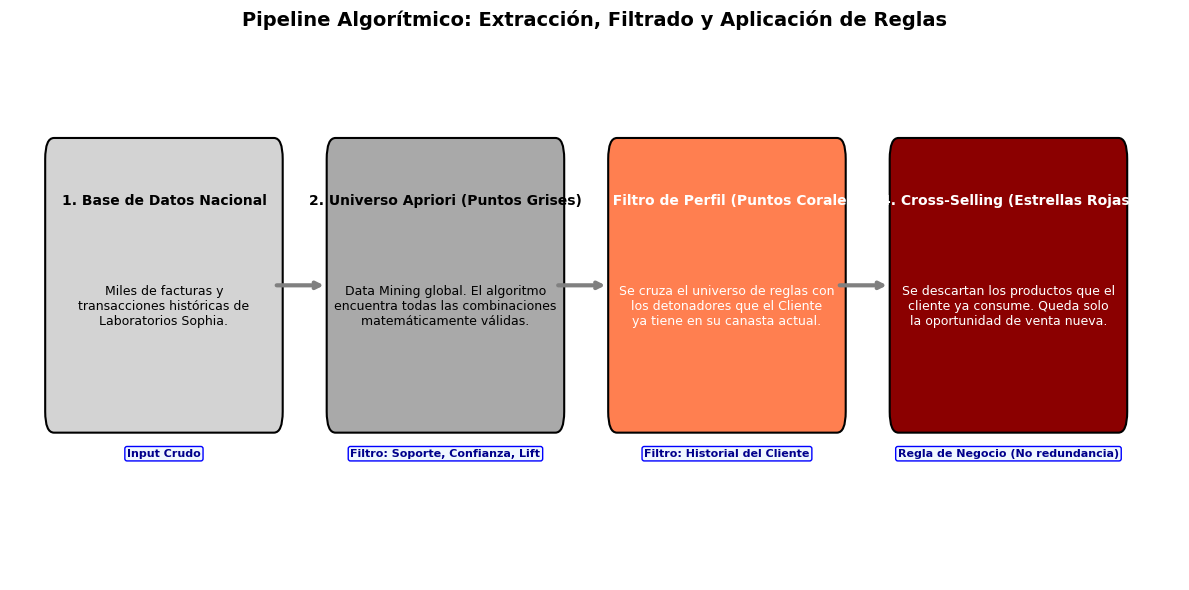

In [ ]:
# =====================================================================
# CELDA 12: ARQUITECTURA DEL MOTOR DE REGLAS (EL EMBUDO B2B)
# =====================================================================
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from IPython.display import display, Markdown

display(Markdown("## ⚙️ Arquitectura del Motor: De la Canasta Nacional a la Sugerencia Táctica"))
display(Markdown("Este diagrama explica el flujo de procesamiento de datos (Pipeline). Muestra cómo el sistema extrae el conocimiento global del mercado (los puntos grises) y lo filtra algorítmicamente hasta obtener recomendaciones de Cross-Selling precisas y no redundantes para el cliente."))

fig, ax = plt.subplots(figsize=(12, 6))

# Definir los pasos del embudo
pasos = [
    {
        "titulo": "1. Base de Datos Nacional",
        "desc": "Miles de facturas y\ntransacciones históricas de\nLaboratorios Sophia.",
        "color": "#D3D3D3", # Gris claro
        "metricas": "Input Crudo"
    },
    {
        "titulo": "2. Universo Apriori (Puntos Grises)",
        "desc": "Data Mining global. El algoritmo\nencuentra todas las combinaciones\nmatemáticamente válidas.",
        "color": "#A9A9A9", # Gris oscuro
        "metricas": "Filtro: Soporte, Confianza, Lift"
    },
    {
        "titulo": "3. Filtro de Perfil (Puntos Corales)",
        "desc": "Se cruza el universo de reglas con\nlos detonadores que el Cliente\nya tiene en su canasta actual.",
        "color": "#FF7F50", # Coral
        "metricas": "Filtro: Historial del Cliente"
    },
    {
        "titulo": "4. Cross-Selling (Estrellas Rojas)",
        "desc": "Se descartan los productos que el\ncliente ya consume. Queda solo\nla oportunidad de venta nueva.",
        "color": "#8B0000", # Rojo oscuro
        "metricas": "Regla de Negocio (No redundancia)"
    }
]

# Dibujar las cajas y flechas
x_start = 0.5
y_start = 0.8
box_width = 2.5
box_height = 1.2
spacing = 3.2

for i, paso in enumerate(pasos):
    x_pos = x_start + (i * spacing)

    # Dibujar la caja principal
    caja = patches.FancyBboxPatch(
        (x_pos, y_start), box_width, box_height,
        boxstyle="round,pad=0.1", ec="black", fc=paso["color"], lw=1.5
    )
    ax.add_patch(caja)

    # Texto del título
    ax.text(x_pos + box_width/2, y_start + box_height - 0.2, paso["titulo"],
            ha='center', va='center', fontsize=10, fontweight='bold', color='black' if i < 2 else 'white')

    # Texto de la descripción
    ax.text(x_pos + box_width/2, y_start + box_height/2 - 0.1, paso["desc"],
            ha='center', va='center', fontsize=9, color='black' if i < 2 else 'white')

    # Etiqueta de la métrica (Filtro aplicado) debajo de la caja
    ax.text(x_pos + box_width/2, y_start - 0.2, paso["metricas"],
            ha='center', va='center', fontsize=8, fontweight='bold', color='darkblue',
            bbox=dict(facecolor='aliceblue', edgecolor='blue', boxstyle='round,pad=0.2'))

    # Flechas conectoras (excepto para el último)
    if i < len(pasos) - 1:
        ax.annotate("",
                    xy=(x_pos + box_width + 0.6, y_start + box_height/2),
                    xytext=(x_pos + box_width, y_start + box_height/2),
                    arrowprops=dict(arrowstyle="->", lw=3, color="gray"))

ax.set_xlim(0, x_start + (len(pasos) * spacing))
ax.set_ylim(0, 2.5)
ax.axis('off')
ax.set_title("Pipeline Algorítmico: Extracción, Filtrado y Aplicación de Reglas", fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()